# Visualisation Deepdive

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AiMTT-project/use-case-1/blob/main/2.3%20Visualisatie/Assignment-Solution/visualisation_deepdive_answers.ipynb)


### Introduction to Crowd Data Visualisation

Crowd data visualisation supports decision-making in safety contexts by making complex information quickly understandable. The design of a visualisation directly influences how users interpret situations and respond.

#### 1. Effect on the User
Visualisations shape perception and behaviour:

- Clear and simple visuals enable fast understanding  
- Colours communicate urgency (e.g. red = danger)  
- Too much complexity increases cognitive load  
- Consistency improves trust and usability  

#### 2. Standards and Target Audience
Visualisations should match the needs of safety professionals (e.g. emergency services). Common practices include:

- Standard colour scales (green → red)  
- Defined thresholds for crowd levels  
- Simple, recognizable symbols  

This ensures reliable interpretation, especially under pressure.

#### 3. Maps, Graphs, and Thresholds
- **Maps** show where crowds are located  
- **Graphs** show how crowds change over time  

A common approach is using threshold values (e.g. 45 / 65 / 85):
- Low → Medium → High → Critical  

These thresholds should be **consistent across all map layers** to avoid confusion and ensure comparability.

#### 4. Styling in Geo Viewers
Different styling methods are used in geospatial applications:
- **SLD** (by the Open Geospatial Consortium): standardised but complex  
- **GeoStyler**: user-friendly tool to create and convert styles  
- **Mapbox styles** (Mapbox): flexible and widely used in web maps  

#### Key Point
Effective crowd visualisation requires **clarity, consistency, and alignment with user needs and domain standards**.

In [ ]:
!pip install geopandas contextily matplotlib numpy

### Import necessary libraries

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import matplotlib.patches as mpatches
import xml.etree.ElementTree as ET
import json
from matplotlib.patches import Patch
import matplotlib.dates as mdates



### Define functions

In [ ]:
# @title


def parse_sld(sld_xml):
    """
    Parse an SLD XML string and extract styling rules.

    Returns a list of rules like:
    [
        {
            "name": "0-45%",
            "property": "capacity",
            "lower": 0.0,
            "lower_op": "PropertyIsGreaterThanOrEqualTo",
            "upper": 45.0,
            "upper_op": "PropertyIsLessThan",
            "fill": "#4CAF50",
            "fill_opacity": 0.8,
            "stroke": "#000000",
            "stroke_width": 1.0,
        },
        ...
    ]
    """
    ns = {
        "sld": "http://www.opengis.net/sld",
        "ogc": "http://www.opengis.net/ogc",
    }

    root = ET.fromstring(sld_xml)
    rules = []

    for rule in root.findall(".//sld:Rule", ns):
        rule_dict = {
            "name": rule.findtext("sld:Title", default="", namespaces=ns),
            "property": None,
            "lower": None,
            "lower_op": None,
            "upper": None,
            "upper_op": None,
            "fill": "#cccccc",
            "fill_opacity": 1.0,
            "stroke": "#000000",
            "stroke_width": 1.0,
        }

        # Parse filter bounds
        filter_el = rule.find("ogc:Filter", ns)
        if filter_el is not None:
            and_el = filter_el.find("ogc:And", ns)
            comparisons = list(and_el) if and_el is not None else list(filter_el)

            for comp in comparisons:
                tag = comp.tag.split("}")[-1]

                prop_name = comp.findtext("ogc:PropertyName", default=None, namespaces=ns)
                literal = comp.findtext("ogc:Literal", default=None, namespaces=ns)

                if prop_name is not None:
                    rule_dict["property"] = prop_name
                if literal is not None:
                    literal = float(literal)

                if tag in ("PropertyIsGreaterThan", "PropertyIsGreaterThanOrEqualTo"):
                    rule_dict["lower"] = literal
                    rule_dict["lower_op"] = tag
                elif tag in ("PropertyIsLessThan", "PropertyIsLessThanOrEqualTo"):
                    rule_dict["upper"] = literal
                    rule_dict["upper_op"] = tag

        # Parse symbolizer
        poly = rule.find("sld:PolygonSymbolizer", ns)
        if poly is not None:
            fill = poly.find("sld:Fill", ns)
            if fill is not None:
                for css in fill.findall("sld:CssParameter", ns):
                    name = css.attrib.get("name")
                    value = (css.text or "").strip()
                    if name == "fill":
                        rule_dict["fill"] = value
                    elif name == "fill-opacity":
                        rule_dict["fill_opacity"] = float(value)

            stroke = poly.find("sld:Stroke", ns)
            if stroke is not None:
                for css in stroke.findall("sld:CssParameter", ns):
                    name = css.attrib.get("name")
                    value = (css.text or "").strip()
                    if name == "stroke":
                        rule_dict["stroke"] = value
                    elif name == "stroke-width":
                        rule_dict["stroke_width"] = float(value)

        rules.append(rule_dict)

    return rules


def value_matches_rule(value, rule):
    """Check whether a numeric value matches an SLD rule."""
    lower_ok = True
    upper_ok = True

    if rule["lower"] is not None:
        if rule["lower_op"] == "PropertyIsGreaterThan":
            lower_ok = value > rule["lower"]
        elif rule["lower_op"] == "PropertyIsGreaterThanOrEqualTo":
            lower_ok = value >= rule["lower"]

    if rule["upper"] is not None:
        if rule["upper_op"] == "PropertyIsLessThan":
            upper_ok = value < rule["upper"]
        elif rule["upper_op"] == "PropertyIsLessThanOrEqualTo":
            upper_ok = value <= rule["upper"]

    return lower_ok and upper_ok


def plot_with_sld_style(gdf, sld_xml, moment, ax=None):
    """
    Plot crowd capacity using styles parsed from an SLD XML string.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain at least: area, time, capacity, geometry
    sld_xml : str
        SLD XML as string
    moment : pandas.Timestamp or datetime
        Time to visualise; closest record per area is selected
    ax : matplotlib axis, optional
    """
    rules = parse_sld(sld_xml)

    if not rules:
        raise ValueError("No SLD rules were found in the provided XML.")

    style_property = rules[0]["property"]
    if style_property is None:
        raise ValueError("Could not determine the styled property from the SLD.")

    # Select the closest row for each area at the specified moment
    areas = gdf["area"].unique()
    rows = []
    for area in areas:
        area_data = gdf[gdf["area"] == area]
        idx_closest = (area_data["time"] - moment).abs().idxmin()
        rows.append(area_data.loc[idx_closest])

    gdf_moment = gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf.crs).copy()

    if style_property not in gdf_moment.columns:
        raise ValueError(
            f"Styled property '{style_property}' not found in GeoDataFrame columns."
        )

    def get_style(value):
        for rule in rules:
            if value_matches_rule(value, rule):
                return rule
        return None

    gdf_moment["style_rule"] = gdf_moment[style_property].apply(get_style)
    gdf_moment["fill"] = gdf_moment["style_rule"].apply(
        lambda r: r["fill"] if r is not None else "#cccccc"
    )
    gdf_moment["fill_opacity"] = gdf_moment["style_rule"].apply(
        lambda r: r["fill_opacity"] if r is not None else 1.0
    )
    gdf_moment["stroke"] = gdf_moment["style_rule"].apply(
        lambda r: r["stroke"] if r is not None else "#000000"
    )
    gdf_moment["stroke_width"] = gdf_moment["style_rule"].apply(
        lambda r: r["stroke_width"] if r is not None else 1.0
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # Plot each rule group separately so opacity/stroke can vary
    for _, subset in gdf_moment.groupby(
        gdf_moment["style_rule"].apply(lambda r: r["name"] if r else "Unstyled")
    ):
        first_rule = subset["style_rule"].iloc[0]
        subset.plot(
            ax=ax,
            color=subset["fill"],
            edgecolor=subset["stroke"].iloc[0],
            linewidth=subset["stroke_width"].iloc[0],
            alpha=subset["fill_opacity"].iloc[0],
        )

    # Add capacity label at centroid
    for _, r in gdf_moment.iterrows():
        centroid = r["geometry"].centroid
        ax.text(
            centroid.x,
            centroid.y,
            f"{r['capacity']:.1f}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2"),
        )

    # Add basemap if CRS is projected/known
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)
    except Exception:
        pass

    # Build legend from SLD rules
    legend_patches = [
        mpatches.Patch(color=rule["fill"], label=rule["name"])
        for rule in rules
    ]
    ax.legend(handles=legend_patches, loc="upper left", title="Capacity Thresholds")

    ax.set_title(f"Capacity per Area at {moment.strftime('%Y-%m-%d %H:%M')}")
    ax.set_axis_off()
    plt.show()

def plot_with_geostyler_style(gdf, geostyler_style, moment, ax=None):
    """
    Plot crowd capacity using styles defined in a GeoStyler style dict.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain at least: area, time, capacity, geometry
    geostyler_style : dict
        GeoStyler style dictionary with rules and symbolizers
    moment : pandas.Timestamp or datetime
        Time to visualise; closest record per area is selected
    ax : matplotlib axis, optional
    """
    # Select the closest row for each area at the specified moment
    areas = gdf["area"].unique()
    rows = []
    for area in areas:
        area_data = gdf[gdf["area"] == area]
        idx_closest = (area_data["time"] - moment).abs().idxmin()
        rows.append(area_data.loc[idx_closest])

    gdf_moment = gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf.crs).copy()

    def matches_filter(row, rule):
        # Only supports simple filters as in the example
        if "filter" not in rule:
            return False
        filt = rule["filter"]
        if filt[0] == "&&":
            checks = []
            for cond in filt[1:]:
                op, prop, val = cond
                v = row[prop]
                if op == ">=":
                    checks.append(v >= val)
                elif op == "<":
                    checks.append(v < val)
                elif op == "<=":
                    checks.append(v <= val)
                elif op == ">":
                    checks.append(v > val)
                elif op == "==":
                    checks.append(v == val)
                else:
                    checks.append(False)
            return all(checks)
        return False

    # Assign style rule to each row
    def get_style_rule(row):
        for rule in geostyler_style.get("rules", []):
            if matches_filter(row, rule):
                return rule
        return None

    gdf_moment["style_rule"] = gdf_moment.apply(get_style_rule, axis=1)
    gdf_moment["fill"] = gdf_moment["style_rule"].apply(
        lambda r: r["symbolizers"][0]["color"] if r else "#cccccc"
    )
    gdf_moment["fill_opacity"] = gdf_moment["style_rule"].apply(
        lambda r: r["symbolizers"][0].get("opacity", 1.0) if r else 1.0
    )
    gdf_moment["stroke"] = gdf_moment["style_rule"].apply(
        lambda r: r["symbolizers"][0].get("outlineColor", "#000000") if r else "#000000"
    )
    gdf_moment["stroke_width"] = gdf_moment["style_rule"].apply(
        lambda r: r["symbolizers"][0].get("outlineWidth", 1.0) if r else 1.0
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # Plot each rule group separately so opacity/stroke can vary
    for _, subset in gdf_moment.groupby(
        gdf_moment["style_rule"].apply(lambda r: r["name"] if r else "Unstyled")
    ):
        first_rule = subset["style_rule"].iloc[0]
        subset.plot(
            ax=ax,
            color=subset["fill"],
            edgecolor=subset["stroke"].iloc[0],
            linewidth=subset["stroke_width"].iloc[0],
            alpha=subset["fill_opacity"].iloc[0],
        )

    # Add capacity label at centroid
    for _, r in gdf_moment.iterrows():
        centroid = r["geometry"].centroid
        ax.text(
            centroid.x,
            centroid.y,
            f"{r['capacity']:.1f}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2"),
        )

    # Add basemap if CRS is projected/known
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)
    except Exception:
        pass

    # Build legend from GeoStyler rules
    legend_patches = [
        mpatches.Patch(color=rule["symbolizers"][0]["color"], label=rule["name"])
        for rule in geostyler_style.get("rules", [])
    ]
    ax.legend(handles=legend_patches, loc="upper left", title="Capacity Thresholds")

    ax.set_title(f"Capacity per Area at {moment.strftime('%Y-%m-%d %H:%M')}")
    ax.set_axis_off()
    plt.show()

def apply_mapbox_style(gdf, mapbox_style_template, moment, ax=None):
    """
    Visualize the GeoDataFrame using the Mapbox style template logic.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain at least: area, time, capacity, geometry
    mapbox_style_template : dict
        Mapbox style dictionary with 'layers' and paint rules
    moment : pandas.Timestamp or datetime
        Time to visualise; closest record per area is selected
    ax : matplotlib axis, optional
    """
    # Select the closest row for each area at the specified moment
    areas = gdf["area"].unique()
    rows = []
    for area in areas:
        area_data = gdf[gdf["area"] == area]
        idx_closest = (area_data["time"] - moment).abs().idxmin()
        rows.append(area_data.loc[idx_closest])

    gdf_moment = gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf.crs).copy()

    # Extract paint rules from the first fill layer
    fill_layer = next((l for l in mapbox_style_template["layers"] if l["type"] == "fill"), None)
    paint = fill_layer["paint"]
    fill_color_expr = paint["fill-color"]

    def get_mapbox_color(capacity):
        # Parse the Mapbox 'case' expression
        expr = fill_color_expr
        if expr[0] == "case":
            i = 1
            while i < len(expr) - 1:
                cond = expr[i]
                color = expr[i + 1]
                if isinstance(cond, list) and cond[0] == "<":
                    if capacity < cond[2]:
                        return color
                elif isinstance(cond, list) and cond[0] == "all":
                    checks = []
                    for sub in cond[1:]:
                        op, get_expr, val = sub
                        if op == ">=" and capacity >= val:
                            checks.append(True)
                        elif op == "<" and capacity < val:
                            checks.append(True)
                        elif op == "<=" and capacity <= val:
                            checks.append(True)
                        else:
                            checks.append(False)
                    if all(checks):
                        return color
                i += 2
            return expr[-1]  # default color
        return "#cccccc"

    gdf_moment["fill"] = gdf_moment["capacity"].apply(get_mapbox_color)
    gdf_moment["fill_opacity"] = paint.get("fill-opacity", 1.0)
    gdf_moment["stroke"] = paint.get("fill-outline-color", "#000000")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    gdf_moment.plot(
        ax=ax,
        color=gdf_moment["fill"],
        edgecolor=gdf_moment["stroke"],
        linewidth=1,
        alpha=gdf_moment["fill_opacity"],
    )

    # Add capacity label at centroid
    for _, r in gdf_moment.iterrows():
        centroid = r["geometry"].centroid
        ax.text(
            centroid.x,
            centroid.y,
            f"{r['capacity']:.1f}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2"),
        )

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)
    except Exception:
        pass

    # Build legend from Mapbox style
    legend_patches = [
        mpatches.Patch(color="#4CAF50", label="<45%"),
        mpatches.Patch(color="#FFEB3B", label="45-65%"),
        mpatches.Patch(color="#FF9800", label="65-85%"),
        mpatches.Patch(color="#F44336", label="85-100%"),
    ]
    ax.legend(handles=legend_patches, loc="upper left", title="Capacity Thresholds")

    ax.set_title(f"Capacity per Area at {moment.strftime('%Y-%m-%d %H:%M')}")
    ax.set_axis_off()
    plt.show()

### Retrieve necessary data

The dataset `visualisation_deepdive_data.geojson` contains Crowdscan capacity observations across event zones.

- **Local execution**: The notebook automatically detects the dataset in local or parent directories.
- **Google Colab**: The code cell below automatically downloads the dataset from GitHub into `sample_data/`.
- **Optional manual Colab command**:
  ```bash
  !mkdir -p sample_data
  !wget -q https://raw.githubusercontent.com/AiMTT-project/use-case-1/main/2.3%20Visualisatie/visualisation_deepdive_data.geojson -O sample_data/visualisation_deepdive_data.geojson
  ```

For more details about Crowdscan, visit: https://www.crowdscan.be


In [ ]:
import os
import urllib.request

# Dataset path configuration (compatible with local environments and Google Colab)
data_filename = "visualisation_deepdive_data.geojson"
data_url = "https://raw.githubusercontent.com/AiMTT-project/use-case-1/main/2.3%20Visualisatie/visualisation_deepdive_data.geojson"

candidate_paths = [
    data_filename,
    os.path.join("..", data_filename),
    os.path.join("sample_data", data_filename),
    os.path.join("/content/sample_data", data_filename),
]

crowdscan_path = None
for p in candidate_paths:
    if os.path.exists(p):
        crowdscan_path = p
        break

if crowdscan_path is None:
    os.makedirs("sample_data", exist_ok=True)
    crowdscan_path = os.path.join("sample_data", data_filename)
    print(f"Downloading {data_filename} from GitHub...")
    urllib.request.urlretrieve(data_url, crowdscan_path)
    print(f"Saved to {crowdscan_path}")

print(f"Using dataset: {crowdscan_path}")


In [ ]:
gdf = gpd.read_file(crowdscan_path)

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 2 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


### Understanding the data

First off, we are going to perform some basic exploration of the data we'll be working with. To start, lets explore which attributes the dataset has.

In [ ]:
# Print all columns in gdf and their data types in a clear table
df_gdf_info = pd.DataFrame({
    "Attribute": gdf.columns,
    "Data Type": [gdf[col].dtype for col in gdf.columns]
})
print(df_gdf_info.to_string(index=False))

Attribute                 Data Type
       id                     int32
     area                    object
 capacity                   float64
     time datetime64[ms, UTC+02:00]
 geometry                  geometry


So we are working with a dataset which tracks capacity for multiple locations over a period of time. The capacity in this dataset indicates how much of the crowdcapacity is filled in these areas. Lets see what we can find out about the time granularity and extent of the geodataframe.

In [ ]:
# Print start and end time, and time granularity stats
start_time = gdf['time'].min()
end_time = gdf['time'].max()

print(f"Start time: {start_time}")
print(f"End time: {end_time}")
# Show the most common and average time between datapoints in seconds
# Calculate and print the average time between datapoints, grouped by location
gdf['time'] = pd.to_datetime(gdf['time'])
avg_time_by_location = (
    gdf.sort_values(['area', 'time'])
    .groupby('area')['time']
    .apply(lambda x: x.diff().dropna().mean())
)
print("Average time between datapoints by location:")
print(avg_time_by_location)

Start time: 2025-08-21 11:00:00.810000+02:00
End time: 2025-08-21 19:59:58.395000+02:00
Average time between datapoints by location:
area
NDSM-horizon          0 days 00:00:10.218000
NDSM-kade             0 days 00:00:09.944000
NDSM-plein            0 days 00:00:10.218000
kaap de groene hoop   0 days 00:00:10.236000
Name: time, dtype: timedelta64[ns]


The dataset covers August 21st, spanning from 11:00 to 20:00. It includes data from multiple locations with a time resolution of roughly 10 seconds. Next, we will examine the locations included in the dataset.

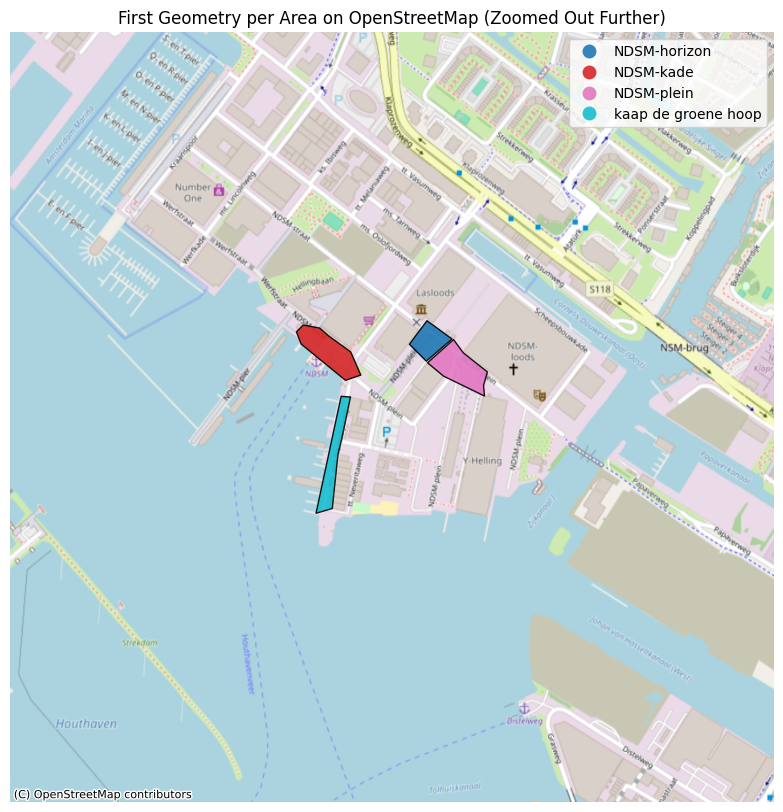

In [ ]:
# Select the first geometry for each area
gdf_first_geom = gdf.sort_values('time').drop_duplicates('area', keep='first')

# Plot only the first geometry for each area, zoomed out for more context
fig, ax = plt.subplots(figsize=(10, 10))
gdf_first_geom.plot(ax=ax, column='area', legend=True, alpha=0.9, edgecolor='k')

# Calculate the total bounds and expand them further for more context
minx, miny, maxx, maxy = gdf_first_geom.total_bounds
pad_x = (maxx - minx) * 1.5  # increase padding for more zoom out
pad_y = (maxy - miny) * 1.5
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)
ax.set_title("First Geometry per Area on OpenStreetMap (Zoomed Out Further)")
plt.axis('off')
plt.show()

So we are exploring multiple areas, all around the NDSM area in Amsterdam Noord, the second day of SAIL 2025. Finally, let's examine the actual capacity the sensors measured on this day.

*Assignment 1:* Visualize the capacity of all areas during the day in a line chart

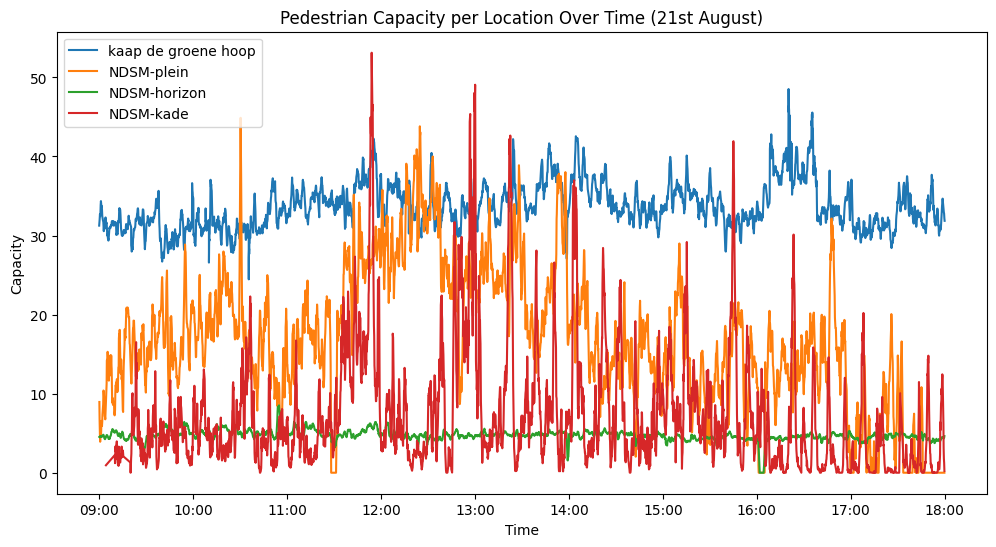

In [ ]:
# Plot capacity for each location over time (21st August)
fig, ax = plt.subplots(figsize=(12, 6))
for area in gdf['area'].unique():
    subset = gdf[gdf['area'] == area]
    ax.plot(pd.to_datetime(subset['time'], format="%m-%d %H:%M"), subset['capacity'], label=area)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel('Time')
ax.set_ylabel('Capacity')
ax.set_title('Pedestrian Capacity per Location Over Time (21st August)')
ax.legend()
plt.show()

### Actionable visualisation

The visualisation you made above is nice trend visualisation. It shows the capacity changing during the day and for analytics it can serve a purpose. However, for information and crowd managers, people who need to divide their attention towards a lot of different people and information, it is more usefull to see how the current trend is progressing compared to set thresholds.

*Assignment 2:* Make a clear map visualisation showing the same trends as before, but now implement the following thresholds.
- Percentage filled: <45%
- Percentage filled: 45 - 65%
- Percentage filled: 65 - 85%
- Percentage filled: 85 - 100%

Think carefully about the colors you're using for each threshold, since colors indicate actions in the world of crowd and information managers (Green==Safe, Orange==Time for actions to keep control, Red==Danger and need to take explicit action to course correct). For reference see the map visualisation you made earlier on in this notebook.

In [ ]:
# Plot capacity for each location over time with threshold bands
fig, ax = plt.subplots(figsize=(12, 6))

# Plot threshold bands as colored backgrounds
ax.axhspan(0, 45, color='#4CAF50', alpha=0.15, label='<45% (Safe)')
ax.axhspan(45, 65, color='#FFEB3B', alpha=0.15, label='45-65% (Caution)')
ax.axhspan(65, 85, color='#FF9800', alpha=0.15, label='65-85% (Warning)')
ax.axhspan(85, 100, color='#F44336', alpha=0.15, label='85-100% (Critical)')

# Plot each area's capacity line
for area_name in gdf['area'].unique():
    area_data = gdf[gdf['area'] == area_name]
    ax.plot(pd.to_datetime(area_data['time']), area_data['capacity'], label=area_name)

ax.set_xlabel('Time')
ax.set_ylabel('Capacity (%)')
ax.set_title('Pedestrian Capacity per Location Over Time with Thresholds')
ax.set_ylim(0, 100)

# Custom legend for thresholds and areas
threshold_patches = [
    Patch(facecolor='#4CAF50', alpha=0.15, label='<45% (Safe)'),
    Patch(facecolor='#FFEB3B', alpha=0.15, label='45-65% (Caution)'),
    Patch(facecolor='#FF9800', alpha=0.15, label='65-85% (Warning)'),
    Patch(facecolor='#F44336', alpha=0.15, label='85-100% (Critical)')
]
area_lines = [ax.lines[i] for i in range(len(gdf['area'].unique()))]
area_labels = gdf['area'].unique()
legend1 = ax.legend(handles=threshold_patches, loc='upper left', title='Thresholds')
legend2 = ax.legend(area_lines, area_labels, loc='upper right', title='Areas')
ax.add_artist(legend1)

plt.show()

### Map visualisations

So far, we have focused on using graphs to visualise trends and support actionable insights. However, this dataset can also be used to assist crowd and information managers through geographic visualisations.

In this section, we explore different ways to communicate crowd capacity in the NDSM area. We begin with a Python-based map visualisation for a single moment in time. Afterwards, we examine different GeoStyler-based approaches, which are commonly used in web GIS viewers.

*Assignment 3*: Provide a map visualisation of the Crowdscan dataset for the selected moment in the code block below, where you implement the same thresholds as before.

In [ ]:
moment = pd.Timestamp('2025-08-21 13:54:02.214000+02:00')

In [ ]:
# Use the specified moment for all areas
# Define thresholds and corresponding colors for capacity percentage
thresholds = [0, 45, 65, 85, 100]
colors = ['#4CAF50', '#FFEB3B', '#FF9800', '#F44336']  # Green, Yellow, Orange, Red

def get_capacity_color(capacity):
    if capacity < thresholds[1]:
        return colors[0]  # Green
    elif capacity < thresholds[2]:
        return colors[1]  # Yellow
    elif capacity < thresholds[3]:
        return colors[2]  # Orange
    else:
        return colors[3]  # Red

# Select the row for each area at the specified moment (closest match per area)
areas = gdf['area'].unique()
rows = []
for area in areas:
    area_data = gdf[gdf['area'] == area]
    # Find the closest time to the moment
    idx_closest = (area_data['time'] - moment).abs().idxmin()
    rows.append(area_data.loc[idx_closest])

gdf_moment = gpd.GeoDataFrame(rows)
gdf_moment['perc_filled'] = gdf_moment['capacity']
gdf_moment['color'] = gdf_moment['perc_filled'].apply(get_capacity_color)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_moment.plot(ax=ax, color=gdf_moment['color'], edgecolor='k', linewidth=1, alpha=0.9)

# Add capacity label at centroid for each area
for _, r in gdf_moment.iterrows():
    centroid = r['geometry'].centroid
    ax.text(
        centroid.x, centroid.y, f"{r['capacity']:.1f}",
        ha='center', va='center', fontsize=14, fontweight='bold',
        color='black', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2')
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)

legend_patches = [
    mpatches.Patch(color=colors[0], label='<45% '),
    mpatches.Patch(color=colors[1], label='45-65% '),
    mpatches.Patch(color=colors[2], label='65-85% '),
    mpatches.Patch(color=colors[3], label='85-100%')
]
ax.legend(handles=legend_patches, loc='upper left', title='Capacity Thresholds')

ax.set_title(f'Capacity per Area at {moment.strftime("%Y-%m-%d %H:%M")}')
plt.axis('off')
plt.show()


### Web GIS Styling Methods

In web-based GIS applications, styling defines how geographic data is visually represented on a map. This includes colours, symbols, classifications (e.g. thresholds), and labels. Different styling approaches exist, each with its own strengths depending on the use case and technical environment.

#### SLD (Styled Layer Descriptor)

SLD is an XML-based standard developed by the Open Geospatial Consortium (OGC). It is widely used in traditional GIS systems such as GeoServer.

- Rule-based styling (e.g. thresholds like 45 / 65 / 85)  
- Strong standardisation and interoperability  
- Less intuitive due to its XML structure  

SLD is particularly useful when working with server-side map rendering and when consistency across systems is important.

---

#### GeoStyler

GeoStyler is a JavaScript-based tool that provides a more user-friendly way to create and manage styles.

- Visual and programmatic style creation  
- Can convert between formats (e.g. SLD ↔ Mapbox)  
- Useful as a bridge between different systems  

GeoStyler is ideal for workflows where multiple styling formats are used or when ease of use is important.

---

#### Mapbox Styles

Mapbox uses a JSON-based styling specification designed for interactive web maps.

- Highly flexible and dynamic styling  
- Well-suited for client-side rendering  
- Supports smooth interactivity and animations  

Mapbox styles are commonly used in modern web applications where performance and user interaction are key.

---

### Key Consideration

Regardless of the method used, it is important to apply **consistent classification and colour schemes** (e.g. threshold values) across all styling approaches. This ensures that users can interpret the map reliably, regardless of the underlying technology.

*Assignment 4.1*: Apply SLD styling for the visualisation below for the Crowdscan dataset. Again, implement clear tresholds and labels. You can play around with different SLD style settings here: https://demo.geostyler.org/.

In [ ]:
sld_xml = """<?xml version="1.0" encoding="UTF-8"?>
<StyledLayerDescriptor version="1.0.0"
    xsi:schemaLocation="http://www.opengis.net/sld StyledLayerDescriptor.xsd"
    xmlns="http://www.opengis.net/sld"
    xmlns:ogc="http://www.opengis.net/ogc"
    xmlns:xlink="http://www.w3.org/1999/xlink"
    xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">
  <NamedLayer>
    <Name>Crowdscan Capacity</Name>
    <UserStyle>
      <Title>Capacity Thresholds</Title>
      <FeatureTypeStyle>

        <Rule>
          <Name>0-45%</Name>
          <Title>0-45%</Title>
          <ogc:Filter>
            <ogc:And>
              <ogc:PropertyIsGreaterThanOrEqualTo>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>0</ogc:Literal>
              </ogc:PropertyIsGreaterThanOrEqualTo>
              <ogc:PropertyIsLessThan>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>45</ogc:Literal>
              </ogc:PropertyIsLessThan>
            </ogc:And>
          </ogc:Filter>
          <PolygonSymbolizer>
            <Fill>
              <CssParameter name="fill">#4CAF50</CssParameter>
              <CssParameter name="fill-opacity">0.8</CssParameter>
            </Fill>
            <Stroke>
              <CssParameter name="stroke">#000000</CssParameter>
              <CssParameter name="stroke-width">1</CssParameter>
            </Stroke>
          </PolygonSymbolizer>
        </Rule>

        <Rule>
          <Name>45-65%</Name>
          <Title>45-65%</Title>
          <ogc:Filter>
            <ogc:And>
              <ogc:PropertyIsGreaterThanOrEqualTo>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>45</ogc:Literal>
              </ogc:PropertyIsGreaterThanOrEqualTo>
              <ogc:PropertyIsLessThan>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>65</ogc:Literal>
              </ogc:PropertyIsLessThan>
            </ogc:And>
          </ogc:Filter>
          <PolygonSymbolizer>
            <Fill>
              <CssParameter name="fill">#FFEB3B</CssParameter>
              <CssParameter name="fill-opacity">0.8</CssParameter>
            </Fill>
            <Stroke>
              <CssParameter name="stroke">#000000</CssParameter>
              <CssParameter name="stroke-width">1</CssParameter>
            </Stroke>
          </PolygonSymbolizer>
        </Rule>

        <Rule>
          <Name>65-85%</Name>
          <Title>65-85%</Title>
          <ogc:Filter>
            <ogc:And>
              <ogc:PropertyIsGreaterThanOrEqualTo>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>65</ogc:Literal>
              </ogc:PropertyIsGreaterThanOrEqualTo>
              <ogc:PropertyIsLessThan>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>85</ogc:Literal>
              </ogc:PropertyIsLessThan>
            </ogc:And>
          </ogc:Filter>
          <PolygonSymbolizer>
            <Fill>
              <CssParameter name="fill">#FF9800</CssParameter>
              <CssParameter name="fill-opacity">0.8</CssParameter>
            </Fill>
            <Stroke>
              <CssParameter name="stroke">#000000</CssParameter>
              <CssParameter name="stroke-width">1</CssParameter>
            </Stroke>
          </PolygonSymbolizer>
        </Rule>

        <Rule>
          <Name>85-100%</Name>
          <Title>85-100%</Title>
          <ogc:Filter>
            <ogc:And>
              <ogc:PropertyIsGreaterThanOrEqualTo>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>85</ogc:Literal>
              </ogc:PropertyIsGreaterThanOrEqualTo>
              <ogc:PropertyIsLessThanOrEqualTo>
                <ogc:PropertyName>capacity</ogc:PropertyName>
                <ogc:Literal>100</ogc:Literal>
              </ogc:PropertyIsLessThanOrEqualTo>
            </ogc:And>
          </ogc:Filter>
          <PolygonSymbolizer>
            <Fill>
              <CssParameter name="fill">#F44336</CssParameter>
              <CssParameter name="fill-opacity">0.8</CssParameter>
            </Fill>
            <Stroke>
              <CssParameter name="stroke">#000000</CssParameter>
              <CssParameter name="stroke-width">1</CssParameter>
            </Stroke>
          </PolygonSymbolizer>
        </Rule>

      </FeatureTypeStyle>
    </UserStyle>
  </NamedLayer>
</StyledLayerDescriptor>
"""

print(sld_xml)


In [ ]:
plot_with_sld_style(gdf, sld_xml, moment)

*Assignment 4.2:* Apply Geostyler styling for the visualisation below for the Crowdscan dataset. Again, implement clear tresholds and labels. You can play around with different Geostyler settings here: https://demo.geostyler.org/.

It's also possible to upload the LOS_deepdive_data.geojson on this website to do some styling that exactly matches on our dataset

In [ ]:
geostyler_style = {
    "name": "Crowdscan Capacity Thresholds",
    "rules": []

}

print(json.dumps(geostyler_style, indent=2))

In [ ]:
geostyler_style = {
  "name": "Crowdscan Capacity Thresholds",
  "rules": [
    {
      "name": "0-45%",
      "filter": [
        "&&",
        [
          ">=",
          "capacity",
          0
        ],
        [
          "<",
          "capacity",
          45
        ]
      ],
      "symbolizers": [
        {
          "kind": "Fill",
          "color": "#4CAF50",
          "opacity": 0.8,
          "outlineColor": "#000000",
          "outlineWidth": 1
        }
      ]
    },
    {
      "name": "45-65%",
      "filter": [
        "&&",
        [
          ">=",
          "capacity",
          45
        ],
        [
          "<",
          "capacity",
          65
        ]
      ],
      "symbolizers": [
        {
          "kind": "Fill",
          "color": "#FFEB3B",
          "opacity": 0.8,
          "outlineColor": "#000000",
          "outlineWidth": 1
        }
      ]
    },
    {
      "name": "65-85%",
      "filter": [
        "&&",
        [
          ">=",
          "capacity",
          65
        ],
        [
          "<",
          "capacity",
          85
        ]
      ],
      "symbolizers": [
        {
          "kind": "Fill",
          "color": "#FF9800",
          "opacity": 0.8,
          "outlineColor": "#000000",
          "outlineWidth": 1
        }
      ]
    },
    {
      "name": "85-100%",
      "filter": [
        "&&",
        [
          ">=",
          "capacity",
          85
        ],
        [
          "<=",
          "capacity",
          100
        ]
      ],
      "symbolizers": [
        {
          "kind": "Fill",
          "color": "#F44336",
          "opacity": 0.8,
          "outlineColor": "#000000",
          "outlineWidth": 1
        }
      ]
    }
  ]
}

In [ ]:
plot_with_geostyler_style(gdf, geostyler_style, moment)

*Assignment 4.3:* Apply Mapbox styling for the visualisation below for the Crowdscan dataset. Again, implement clear tresholds and labels. You can play around with different Mapbox settings here: https://demo.geostyler.org/.

In [ ]:
mapbox_style_template = {
    "version": 8,
    "name": "Crowdscan Capacity Thresholds",
    "sources": {
        "crowdscan": {
            "type": "geojson",
            "data": crowdscan_path
        }
    },
    "layers": [
        {
            "id": "capacity-fill",
            "type": "fill",
            "source": "crowdscan",
            "paint": {
                "fill-color": [
                    "case",
                    ["<", ["get", "capacity"], 45], "#4CAF50",
                    ["all", [">=", ["get", "capacity"], 45], ["<", ["get", "capacity"], 65]], "#FFEB3B",
                    ["all", [">=", ["get", "capacity"], 65], ["<", ["get", "capacity"], 85]], "#FF9800",
                    ["all", [">=", ["get", "capacity"], 85], ["<=", ["get", "capacity"], 100]], "#F44336",
                    "#cccccc"
                ],
                "fill-opacity": 0.8,
                "fill-outline-color": "#000000"
            }
        }
    ]
}

print(json.dumps(mapbox_style_template, indent=2))

In [ ]:
apply_mapbox_style(gdf, mapbox_style_template, moment)

## Conclusion

In this notebook, we explored how crowd capacity data can be visualised to support decision-making in safety contexts.

We started by analysing temporal patterns using graphs, which helped us understand how crowd levels evolve over time and identify key trends. These visualisations are valuable for monitoring and retrospective analysis.

Next, we shifted to map-based visualisations, where spatial context becomes essential. By visualising capacity per area on a map, we can better support operational decisions, such as identifying high-risk zones and prioritising interventions.

A key concept throughout the notebook was the use of **thresholds** (e.g. 45 / 65 / 85) to classify crowd levels. Applying these thresholds consistently ensures that visualisations remain clear, interpretable, and aligned with domain standards.

Finally, we explored different styling approaches, including Python-based implementations and SLD-based styling. By working with SLD templates, we demonstrated how styling rules can be defined in a structured and reusable way, enabling interoperability with web GIS systems.

### Key Takeaways

- Effective visualisation combines **clarity, consistency, and context**  
- Graphs and maps serve complementary purposes (temporal vs spatial insight)  
- Consistent thresholds are essential for reliable interpretation  
- Standardised styling methods (like SLD) improve scalability and reuse  

Overall, this notebook shows how data visualisation can move beyond simple representation and become a practical tool for **decision support in crowd management**.